In [3]:
import geopandas as gpd
import sys
import os
import matplotlib as plt

In [ ]:
def shapefile_to_geojson(shapefile_path, output_geojson_path=None):
    # Read the shapefile
    gdf = gpd.read_file(shapefile_path)
    gdf = gdf.to_crs(epsg=3857)
    
    # If output path is not specified, create it
    if output_geojson_path is None:
        output_geojson_path = os.path.splitext(shapefile_path)[0] + ".geojson"
    
    # Save to GeoJSON
    gdf.to_file(output_geojson_path, driver="GeoJSON")
    
    print(f"Converted {shapefile_path} to {output_geojson_path}")


In [4]:
shapefile_path = '/Users/beckyxu/Documents/GitHub/Carbon_Offset_Validation/carbon-offset-validator/data/shapefiles/Indonesia_oil_palm_concessions/Indonesia_oil_palm_concessions.shp'
output_geojson_path = '/Users/beckyxu/Documents/GitHub/Carbon_Offset_Validation/carbon-offset-validator/data/shapefiles/Indonesia_oil_palm_concessions/Indonesia_oil_palm_concessions.geojson'
# shapefile_to_geojson(shapefile_path, output_geojson_path)

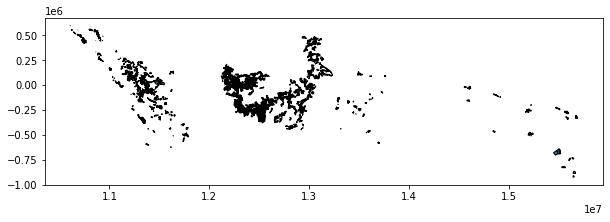

In [ ]:
gdf = gpd.read_file(output_geojson_path)

# Plot it
gdf.plot(figsize=(10, 10), edgecolor='black')

In [ ]:
os.chdir("/Users/beckyxu/Documents/GitHub/Carbon_Offset_Validation/carbon-offset-validator/server-python/")
import geojson
from shapely.geometry import shape
from shapely.wkt import dumps
import os
from database import supabase

def upload_to_supabase(filepath, table_name: str = "other_geo_data"):
    """Upload GeoJSON to Supabase with project_code matching"""
    try:
        # Set working directory to file's directory (optional)
        os.chdir(os.path.dirname(os.path.abspath(filepath)))

        # Load GeoJSON file
        with open(os.path.basename(filepath)) as f:
            gj = geojson.load(f)

        # Insert into Supabase
        response = supabase.table(table_name).insert({
            "name": "Palm Oil Concession Indonesia 2025",
            "geojson": gj
        }).execute()    

        print("Upload complete!")
        return response

    except Exception as e:
        print(f"Error uploading to Supabase: {str(e)}")
        return None

In [16]:
upload_to_supabase(output_geojson_path)

Error uploading to Supabase: The read operation timed out
